# ВЭС — safe_features ≈ 7.48 + layout/wake features

Этот ноутбук обучает основной `safe_features` вариант и отдельный необычный кандидат:

```text
safe_features + layout_wake
```

Layout/wake-блок использует координаты турбин из файла:

```text
data/azov_turbines_from_map.csv
```

Главные файлы после запуска:

```text
outputs/pipeline_747/submission_safe_features_exact_747.csv
outputs/pipeline_747/submission_safe_features_layout_wake_747.csv
```

Первый — стабильный скоринговый вариант.  
Второй — необычный layout-aware / wake-aware кандидат для жюри.


In [ ]:
# -*- coding: utf-8 -*-

import warnings
from pathlib import Path

import numpy as np
import pandas as pd

from scipy.interpolate import PchipInterpolator
from sklearn.isotonic import IsotonicRegression
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error

from catboost import CatBoostRegressor
from xgboost import XGBRegressor
import lightgbm as lgb

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

INSTALLED_CAPACITY_MW = 90.09
TURBINES_TOTAL = 26
CUT_IN_SPEED = 3.0
RATED_SPEED = 12.0
CUT_OUT_SPEED = 25.0
AIR_DENSITY_REF = 1.225
EPS = 1e-6

NWP_SHIFTS = [-6, -3, -2, -1, 1, 2, 3, 6]

DATA_DIR = Path("data")
OUTPUT_DIR = Path("outputs") / "pipeline_747"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_CANDIDATES = [
    DATA_DIR / "merged_dataset.csv",
    DATA_DIR / "train_dataset.csv",
]

VALID_CANDIDATES = [
    DATA_DIR / "merged_valid_dataset.csv",
    DATA_DIR / "valid_features.csv",
]

TRAIN_PATH = next((p for p in TRAIN_CANDIDATES if p.exists()), TRAIN_CANDIDATES[0])
VALID_PATH = next((p for p in VALID_CANDIDATES if p.exists()), VALID_CANDIDATES[0])

BASELINE_SUBMISSION_PATH = OUTPUT_DIR / "submission_baseline_exact_747.csv"
SAFE_SUBMISSION_PATH = OUTPUT_DIR / "submission_safe_features_exact_747.csv"
SAFE_LOCAL_CHECK_PATH = OUTPUT_DIR / "exact_747_local_check.csv"

BLEND_WEIGHTS = {
    "cat_mae_direct": 0.361831,
    "hgb_q545": 0.235409,
    "xgb_residual": 0.177644,
    "hgb_q570": 0.116581,
    "lgb_residual": 0.064663,
    "hgb_q530": 0.043873,
}

print("TRAIN_PATH:", TRAIN_PATH)
print("VALID_PATH:", VALID_PATH)

TRAIN_PATH: data\merged_dataset.csv
VALID_PATH: data\merged_valid_dataset.csv


## 1. Загрузка данных

In [2]:
print("1. Загрузка данных...")

if not TRAIN_PATH.exists():
    raise FileNotFoundError(f"Не найден train-файл: {TRAIN_PATH}")

if not VALID_PATH.exists():
    raise FileNotFoundError(f"Не найден valid-файл: {VALID_PATH}")

train_raw = pd.read_csv(TRAIN_PATH)
valid_raw = pd.read_csv(VALID_PATH)

print("train_raw:", train_raw.shape)
print("valid_raw:", valid_raw.shape)

TARGET_CANDIDATES = [
    "Выработка. Результирующий расчет",
    "target",
    "Выработка",
]

DATETIME_CANDIDATES = [
    "METEOFORECASTHOUR_OPENM_Datetime",
    "Datetime",
    "datetime",
    "date",
    "time",
]

REPAIR_CANDIDATES = [
    "Кол-во_ВЭУ_в_ремонте",
    "turbines_in_repair",
    "repair",
]

target_col = None
for c in TARGET_CANDIDATES:
    if c in train_raw.columns and c not in valid_raw.columns:
        target_col = c
        break

if target_col is None:
    diff_cols = [c for c in train_raw.columns if c not in valid_raw.columns]
    if len(diff_cols) == 0:
        raise ValueError("Не найден target.")
    target_col = diff_cols[0]

datetime_col = None
for c in DATETIME_CANDIDATES:
    if c in train_raw.columns and c in valid_raw.columns:
        datetime_col = c
        break

if datetime_col is None:
    raise ValueError("Не найдена datetime-колонка.")

repair_col = None
for c in REPAIR_CANDIDATES:
    if c in train_raw.columns and c in valid_raw.columns:
        repair_col = c
        break

if repair_col is None:
    common_cols = [c for c in train_raw.columns if c in valid_raw.columns]
    repair_col = common_cols[-1]

print("target_col:", target_col)
print("datetime_col:", datetime_col)
print("repair_col:", repair_col)

train = train_raw.rename(
    columns={
        datetime_col: "datetime",
        target_col: "target",
        repair_col: "turbines_in_repair",
    }
).copy()

valid = valid_raw.rename(
    columns={
        datetime_col: "datetime",
        repair_col: "turbines_in_repair",
    }
).copy()

if not train.columns.is_unique:
    print("train duplicate columns:", train.columns[train.columns.duplicated()].tolist())
    train = train.loc[:, ~train.columns.duplicated()].copy()

if not valid.columns.is_unique:
    print("valid duplicate columns:", valid.columns[valid.columns.duplicated()].tolist())
    valid = valid.loc[:, ~valid.columns.duplicated()].copy()

train["datetime"] = pd.to_datetime(train["datetime"], errors="coerce")
valid["datetime"] = pd.to_datetime(valid["datetime"], errors="coerce")

train["row_id"] = np.arange(len(train))
valid["row_id"] = np.arange(len(valid))

train["source"] = "train"
valid["source"] = "valid"

train = train.sort_values("datetime").reset_index(drop=True)
valid = valid.sort_values("datetime").reset_index(drop=True)

print("train:", train.shape)
print("valid:", valid.shape)
display(train.head())
display(valid.head())

1. Загрузка данных...
train_raw: (32434, 36)
valid_raw: (2126, 35)
target_col: Выработка. Результирующий расчет
datetime_col: METEOFORECASTHOUR_OPENM_Datetime
repair_col: Кол-во_ВЭУ_в_ремонте
train: (32434, 38)
valid: (2126, 37)


,datetime,month,hour_of_day,target,wind_speed_10m,wind_speed_80m,wind_speed_120m,wind_speed_180m,wind_direction_10m,wind_direction_80m,...,QV2M,PS,WS10M,WD10M,WS50M,WD50M,T2MWET,WSC,row_id,source
0,2022-01-01 00:00:00,1,0,0.697,2.77,4.27,4.62,NaN,0.244,0.249,...,2.98,101.36,1.70,272.4,2.07,271.9,-2.24,2.87,32433,train
1,2022-01-01 01:00:00,1,1,4.413,2.91,4.40,4.78,NaN,0.243,0.249,...,2.99,101.32,2.10,259.0,2.59,258.6,-2.22,3.59,32432,train
2,2022-01-01 02:00:00,1,2,5.362,3.11,4.92,5.36,NaN,0.237,0.246,...,3.00,101.30,2.69,248.9,3.38,248.5,-2.23,4.68,32431,train
3,2022-01-01 03:00:00,1,3,4.879,3.02,4.66,5.14,NaN,0.236,0.247,...,3.03,101.26,3.28,240.2,4.19,240.1,-2.18,5.80,32430,train
4,2022-01-01 04:00:00,1,4,6.309,3.26,4.50,4.82,NaN,0.220,0.233,...,3.10,101.22,3.76,232.5,4.87,232.4,-2.00,6.75,32429,train


,datetime,month,hour_of_day,wind_speed_10m,wind_speed_80m,wind_speed_120m,wind_speed_180m,wind_direction_10m,wind_direction_80m,wind_direction_120m,...,QV2M,PS,WS10M,WD10M,WS50M,WD50M,T2MWET,WSC,row_id,source
0,2026-01-01 00:00:00,1,0,4.02,6.80,7.70,8.11,0.264,0.270,0.271,...,2.01,100.49,6.52,258.4,9.17,258.7,-5.90,12.70,2125,valid
1,2026-01-01 01:00:00,1,1,3.76,6.66,7.83,8.42,0.253,0.262,0.265,...,2.08,100.52,6.66,255.6,9.29,255.9,-5.67,12.87,2124,valid
2,2026-01-01 02:00:00,1,2,3.45,6.86,8.97,10.08,0.240,0.251,0.256,...,2.17,100.56,6.83,255.3,9.43,255.8,-5.29,13.06,2123,valid
3,2026-01-01 03:00:00,1,3,4.14,7.45,9.31,10.57,0.250,0.258,0.261,...,2.29,100.60,6.86,260.1,9.31,260.5,-4.96,12.90,2122,valid
4,2026-01-01 04:00:00,1,4,4.63,7.98,9.33,10.11,0.256,0.262,0.265,...,2.35,100.64,6.63,267.9,8.92,268.2,-4.97,12.36,2121,valid


## 2. Базовые признаки и safe-блоки EXACT

In [3]:
print("2. Генерация признаков...")

full = pd.concat([train, valid], ignore_index=True, sort=False)
full = full.sort_values("datetime").reset_index(drop=True)

SAFE_FEATURE_BLOCKS = {
    "shear": [],
    "cap13": [],
    "direction_sectors": [],
    "nasa_openm_disagreement": [],
    "isotonic": [],
}

# ------------------------------------------------------------
# Время
# ------------------------------------------------------------

full["month"] = full["datetime"].dt.month
full["hour_of_day"] = full["datetime"].dt.hour
full["dayofyear"] = full["datetime"].dt.dayofyear
full["dayofweek"] = full["datetime"].dt.dayofweek

full["hour_sin"] = np.sin(2 * np.pi * full["hour_of_day"] / 24)
full["hour_cos"] = np.cos(2 * np.pi * full["hour_of_day"] / 24)

full["month_sin"] = np.sin(2 * np.pi * full["month"] / 12)
full["month_cos"] = np.cos(2 * np.pi * full["month"] / 12)

full["dayofyear_sin"] = np.sin(2 * np.pi * full["dayofyear"] / 366)
full["dayofyear_cos"] = np.cos(2 * np.pi * full["dayofyear"] / 366)

# ------------------------------------------------------------
# Ветер
# ------------------------------------------------------------

speed_cols = [
    "wind_speed_10m",
    "wind_speed_80m",
    "wind_speed_120m",
    "wind_speed_180m",
]

direction_cols = [
    "wind_direction_10m",
    "wind_direction_80m",
    "wind_direction_120m",
    "wind_direction_180m",
]

speed_cols = [c for c in speed_cols if c in full.columns]
direction_cols = [c for c in direction_cols if c in full.columns]

for col in speed_cols:
    full[f"{col}_sq"] = full[col] ** 2
    full[f"{col}_cube"] = full[col] ** 3

for col in direction_cols:
    suffix = col.replace("wind_direction_", "")
    angle = np.deg2rad(full[col] * 1000)

    full[f"wind_dir_{suffix}_sin"] = np.sin(angle)
    full[f"wind_dir_{suffix}_cos"] = np.cos(angle)

if "wind_speed_120m" in full.columns:
    full["ws_120_cube"] = full["wind_speed_120m"] ** 3

if {"wind_speed_120m", "wind_speed_80m"}.issubset(full.columns):
    full["ws_diff_120_80"] = full["wind_speed_120m"] - full["wind_speed_80m"]
    full["ws_ratio_120_80"] = full["wind_speed_120m"] / (full["wind_speed_80m"] + EPS)

if {"wind_speed_180m", "wind_speed_120m"}.issubset(full.columns):
    full["ws_diff_180_120"] = full["wind_speed_180m"] - full["wind_speed_120m"]

if {"wind_gusts_10m", "wind_speed_10m"}.issubset(full.columns):
    full["gust_ratio_10m"] = full["wind_gusts_10m"] / (full["wind_speed_10m"] + EPS)

# ------------------------------------------------------------
# Физика
# ------------------------------------------------------------

temperature_mean = 0.5 * (full["temperature_80m"] + full["temperature_120m"])

full["air_density"] = (
    full["pressure_msl"] * 100
) / (287.05 * (temperature_mean + 273.15))

full["density_ratio"] = (
    full["air_density"] / AIR_DENSITY_REF
).clip(0.75, 1.30)

for height in [80, 120]:
    speed_col = f"wind_speed_{height}m"

    if speed_col in full.columns:
        full[f"wind_speed_{height}m_density_corrected"] = (
            full[speed_col] * (full["density_ratio"] ** (1 / 3))
        )

        full[f"wind_power_density_{height}m"] = (
            0.5 * full["air_density"] * full[speed_col] ** 3
        )

availability = (
    (TURBINES_TOTAL - full["turbines_in_repair"])
    .clip(0, TURBINES_TOTAL)
    / TURBINES_TOTAL
)

full["available_capacity_mw"] = availability * INSTALLED_CAPACITY_MW

# ------------------------------------------------------------
# p_theory
# ------------------------------------------------------------

for height in [80, 120]:
    speed_col = f"wind_speed_{height}m"

    if speed_col in full.columns:
        speed = full[speed_col].clip(lower=0)

        curve = (
            (speed ** 3 - CUT_IN_SPEED ** 3)
            / (RATED_SPEED ** 3 - CUT_IN_SPEED ** 3)
        ).clip(0, 1)

        curve = curve.where(speed >= CUT_IN_SPEED, 0)
        curve = curve.where(speed < CUT_OUT_SPEED, 0)

        full[f"p_theory_{height}"] = (
            INSTALLED_CAPACITY_MW * curve * availability
        )

if {"p_theory_80", "p_theory_120"}.issubset(full.columns):
    full["p_theory_mean_80_120"] = (
        0.5 * (full["p_theory_80"] + full["p_theory_120"])
    )

# ------------------------------------------------------------
# EXACT safe block 1: shear
# ------------------------------------------------------------

def add_shear_feature(df, low_h, high_h):
    low_col = f"wind_speed_{low_h}m"
    high_col = f"wind_speed_{high_h}m"
    out_col = f"shear_{low_h}_{high_h}"

    if low_col in df.columns and high_col in df.columns:
        df[out_col] = (
            np.log((df[high_col].clip(lower=EPS)) / (df[low_col].clip(lower=EPS)))
            / np.log(high_h / low_h)
        )
        df[out_col] = df[out_col].replace([np.inf, -np.inf], np.nan)
        SAFE_FEATURE_BLOCKS["shear"].append(out_col)

for low_h, high_h in [(10, 80), (80, 120), (120, 180), (80, 180), (10, 120)]:
    add_shear_feature(full, low_h, high_h)

# ------------------------------------------------------------
# EXACT safe block 2: cap13
# ------------------------------------------------------------

if "wind_speed_120m" in full.columns:
    cap = 13
    base = f"wind120_cap{cap}"

    full[f"{base}_clipped"] = full["wind_speed_120m"].clip(upper=cap)
    full[f"{base}_above"] = (full["wind_speed_120m"] - cap).clip(lower=0)
    full[f"{base}_is_above"] = (full["wind_speed_120m"] > cap).astype(int)
    full[f"{base}_clipped_cube"] = full[f"{base}_clipped"] ** 3

    SAFE_FEATURE_BLOCKS["cap13"] += [
        f"{base}_clipped",
        f"{base}_above",
        f"{base}_is_above",
        f"{base}_clipped_cube",
    ]

# ------------------------------------------------------------
# EXACT safe block 3: direction sectors
# оставляем с NaN-fix, но без изменения самой идеи
# ------------------------------------------------------------

for h in [80, 120, 180]:
    col = f"wind_direction_{h}m"

    if col in full.columns:
        deg = (full[col] * 1000) % 360

        for n_sec in [8, 16]:
            sec_col = f"wind_dir_{h}m_sector_{n_sec}"

            sector = np.floor(deg / (360 / n_sec))
            sector = (
                sector
                .replace([np.inf, -np.inf], np.nan)
                .fillna(-1)
                .clip(-1, n_sec - 1)
                .astype(int)
            )

            full[sec_col] = sector
            SAFE_FEATURE_BLOCKS["direction_sectors"].append(sec_col)

# ------------------------------------------------------------
# EXACT safe block 4: NASA/OpenM disagreement
# ВАЖНО: только тот набор, который был в 7.48-ноутбуке:
# ws10, ws80, pressure, temp80, wd10
# Без ws120/temp120/wd80.
# ------------------------------------------------------------

def add_diff_if_possible(openm_col, nasa_col, new_col):
    if openm_col in full.columns and nasa_col in full.columns:
        full[new_col] = full[openm_col] - full[nasa_col]
        full[new_col] = full[new_col].replace([np.inf, -np.inf], np.nan)
        SAFE_FEATURE_BLOCKS["nasa_openm_disagreement"].append(new_col)

add_diff_if_possible("wind_speed_10m", "WS10M", "ws10_openm_minus_nasa")
add_diff_if_possible("wind_speed_80m", "WS50M", "ws80_openm_minus_nasa50")
add_diff_if_possible("pressure_msl", "PS", "pressure_msl_minus_ps")
add_diff_if_possible("temperature_80m", "T2M", "temp80_minus_t2m")

if "wind_direction_10m" in full.columns and "WD10M" in full.columns:
    openm_deg = (full["wind_direction_10m"] * 1000) % 360
    nasa_deg = full["WD10M"] % 360

    diff = ((openm_deg - nasa_deg + 180) % 360) - 180
    diff = diff.replace([np.inf, -np.inf], np.nan)

    full["wd10_openm_minus_nasa_circular"] = diff
    SAFE_FEATURE_BLOCKS["nasa_openm_disagreement"].append("wd10_openm_minus_nasa_circular")

for block_name in SAFE_FEATURE_BLOCKS:
    SAFE_FEATURE_BLOCKS[block_name] = sorted(list(dict.fromkeys(SAFE_FEATURE_BLOCKS[block_name])))

print("full:", full.shape)
for block_name, cols in SAFE_FEATURE_BLOCKS.items():
    print(block_name, len(cols), cols)

2. Генерация признаков...
full: (34560, 97)
shear 5 ['shear_10_120', 'shear_10_80', 'shear_120_180', 'shear_80_120', 'shear_80_180']
cap13 4 ['wind120_cap13_above', 'wind120_cap13_clipped', 'wind120_cap13_clipped_cube', 'wind120_cap13_is_above']
direction_sectors 6 ['wind_dir_120m_sector_16', 'wind_dir_120m_sector_8', 'wind_dir_180m_sector_16', 'wind_dir_180m_sector_8', 'wind_dir_80m_sector_16', 'wind_dir_80m_sector_8']
nasa_openm_disagreement 5 ['pressure_msl_minus_ps', 'temp80_minus_t2m', 'wd10_openm_minus_nasa_circular', 'ws10_openm_minus_nasa', 'ws80_openm_minus_nasa50']
isotonic 0 []


## 3. EMA и NWP-соседи

In [4]:
print("3. EMA и NWP-соседи...")

full = full.sort_values("datetime").reset_index(drop=True)
time_indexed = full.set_index("datetime")

ewm_spans = {
    "3h": 3,
    "5h": 5,
    "7h": 7,
}

ema_cols = [
    "wind_speed_120m_cube",
    "p_theory_80",
    "p_theory_120",
    "wind_power_density_120m",
]

ema_cols = [c for c in ema_cols if c in full.columns]

for col in ema_cols:
    for window_str, span_val in ewm_spans.items():
        full[f"{col}_smooth_{window_str}"] = (
            time_indexed[col]
            .ewm(span=span_val, min_periods=1)
            .mean()
            .reindex(full["datetime"])
            .to_numpy()
        )

    full[f"{col}_minus_smooth_3h"] = full[col] - full[f"{col}_smooth_3h"]

nwp_base_cols = [
    "wind_speed_80m",
    "wind_speed_120m",
    "wind_speed_120m_cube",
    "wind_speed_120m_density_corrected",
    "p_theory_120",
    "wind_power_density_120m",
]

nwp_base_cols = [c for c in nwp_base_cols if c in full.columns]

for col in nwp_base_cols:
    for shift_hours in NWP_SHIFTS:
        shifted_datetime = full["datetime"] + pd.to_timedelta(shift_hours, unit="h")
        label = f"plus_{shift_hours}h" if shift_hours > 0 else f"minus_{abs(shift_hours)}h"

        full[f"{col}_nwp_{label}"] = (
            time_indexed[col]
            .reindex(shifted_datetime)
            .to_numpy()
        )

print("full:", full.shape)

3. EMA и NWP-соседи...
full: (34560, 161)


## 4. p_empirical: PCHIP + isotonic

In [5]:
print("4. Эмпирическая кривая мощности...")

train_base = (
    full[full["source"].eq("train")]
    .copy()
    .sort_values("datetime")
    .reset_index(drop=True)
)

valid_base = (
    full[full["source"].eq("valid")]
    .copy()
    .sort_values("datetime")
    .reset_index(drop=True)
)

def add_empirical_power_features(frame, reference):
    frame = frame.copy()
    reference = reference.copy()

    ref_available = reference["available_capacity_mw"].clip(lower=1.0)
    reference["cf_available"] = (
        reference["target"] / ref_available
    ).clip(0, 1.15)

    iso_cols = []

    for height in [80, 120]:
        speed_col = f"wind_speed_{height}m_density_corrected"

        if speed_col not in frame.columns or speed_col not in reference.columns:
            continue

        bins = np.arange(0, 26.5, 0.5)

        ref = reference[[speed_col, "cf_available"]].dropna().copy()
        ref["bin_id"] = pd.cut(ref[speed_col], bins=bins, labels=False)

        curve = (
            ref.groupby("bin_id", as_index=False)
            .agg(
                cf=("cf_available", "median"),
                n=("cf_available", "size"),
            )
        )

        curve = curve[curve["n"] >= 20].copy()
        curve["speed"] = bins[curve["bin_id"].astype(int)] + 0.25
        curve = curve.sort_values("speed")

        if len(curve) == 0:
            frame[f"p_empirical_{height}"] = 0.0
            frame[f"cf_empirical_{height}"] = 0.0
            frame[f"p_empirical_iso_{height}"] = 0.0
            frame[f"cf_empirical_iso_{height}"] = 0.0

            iso_cols += [f"p_empirical_iso_{height}", f"cf_empirical_iso_{height}"]
            continue

        cf_monotonic = np.maximum.accumulate(curve["cf"].to_numpy())

        # PCHIP baseline
        x = np.r_[0.0, curve["speed"].to_numpy(), CUT_OUT_SPEED]
        y = np.r_[0.0, cf_monotonic, cf_monotonic[-1]]

        unique_x, unique_idx = np.unique(x, return_index=True)
        unique_y = y[unique_idx]

        interpolator = PchipInterpolator(unique_x, unique_y, extrapolate=True)

        speed_eval = frame[speed_col].clip(0, CUT_OUT_SPEED)

        empirical_cf = np.clip(interpolator(speed_eval), 0, 1.15)
        empirical_cf = np.where(frame[speed_col] < CUT_IN_SPEED, 0, empirical_cf)
        empirical_cf = np.where(frame[speed_col] >= CUT_OUT_SPEED, 0, empirical_cf)

        frame[f"p_empirical_{height}"] = empirical_cf * frame["available_capacity_mw"]
        frame[f"cf_empirical_{height}"] = empirical_cf

        # Isotonic exact block
        iso = IsotonicRegression(
            y_min=0.0,
            y_max=1.15,
            increasing=True,
            out_of_bounds="clip",
        )

        iso.fit(curve["speed"].to_numpy(), curve["cf"].to_numpy())

        empirical_cf_iso = np.clip(iso.predict(speed_eval), 0, 1.15)
        empirical_cf_iso = np.where(frame[speed_col] < CUT_IN_SPEED, 0, empirical_cf_iso)
        empirical_cf_iso = np.where(frame[speed_col] >= CUT_OUT_SPEED, 0, empirical_cf_iso)

        frame[f"p_empirical_iso_{height}"] = empirical_cf_iso * frame["available_capacity_mw"]
        frame[f"cf_empirical_iso_{height}"] = empirical_cf_iso

        iso_cols += [f"p_empirical_iso_{height}", f"cf_empirical_iso_{height}"]

    if {"p_empirical_80", "p_empirical_120"}.issubset(frame.columns):
        frame["p_empirical_mean_80_120"] = (
            0.5 * (frame["p_empirical_80"] + frame["p_empirical_120"])
        )

    if {"p_empirical_iso_80", "p_empirical_iso_120"}.issubset(frame.columns):
        frame["p_empirical_iso_mean_80_120"] = (
            0.5 * (frame["p_empirical_iso_80"] + frame["p_empirical_iso_120"])
        )

        iso_cols.append("p_empirical_iso_mean_80_120")

    if {"p_empirical_120", "p_theory_120"}.issubset(frame.columns):
        frame["p_empirical_minus_theory_120"] = (
            frame["p_empirical_120"] - frame["p_theory_120"]
        )

    return frame, sorted(list(dict.fromkeys(iso_cols)))

train_fe, iso_train_cols = add_empirical_power_features(train_base, train_base)
valid_fe, iso_valid_cols = add_empirical_power_features(valid_base, train_base)

SAFE_FEATURE_BLOCKS["isotonic"] = sorted(
    list(set(iso_train_cols).intersection(set(iso_valid_cols)))
)

print("train_fe:", train_fe.shape)
print("valid_fe:", valid_fe.shape)
print("isotonic:", SAFE_FEATURE_BLOCKS["isotonic"])

4. Эмпирическая кривая мощности...
train_fe: (32434, 172)
valid_fe: (2126, 172)
isotonic: ['cf_empirical_iso_120', 'cf_empirical_iso_80', 'p_empirical_iso_120', 'p_empirical_iso_80', 'p_empirical_iso_mean_80_120']


## 5. Выбор признаков EXACT

In [6]:
raw_cols = [
    "month",
    "hour_of_day",
    "wind_speed_10m",
    "wind_speed_80m",
    "wind_speed_120m",
    "wind_speed_180m",
    "wind_direction_10m",
    "wind_direction_80m",
    "wind_direction_120m",
    "wind_direction_180m",
    "wind_gusts_10m",
    "temperature_80m",
    "temperature_120m",
    "pressure_msl",
    "rain",
    "showers",
    "snowfall",
    "cloud_cover_low",
    "turbines_in_repair",
]

physics_cols = [
    "available_capacity_mw",
    "air_density",
    "density_ratio",
    "wind_power_density_80m",
    "wind_power_density_120m",
    "p_theory_80",
    "p_theory_120",
    "p_theory_mean_80_120",
    "p_empirical_80",
    "p_empirical_120",
    "p_empirical_mean_80_120",
    "p_empirical_minus_theory_120",
    "cf_empirical_80",
    "cf_empirical_120",
]

auto_cols = [
    col for col in train_fe.columns
    if (
        col.endswith("_sq")
        or col.endswith("_cube")
        or col.startswith("wind_dir_")
        or "_smooth_" in col
        or col.endswith("_minus_smooth_3h")
        or "_nwp_" in col
        or col.endswith("_density_corrected")
        or col.startswith("ws_")
        or col.startswith("gust_ratio")
        or col.startswith("dayofyear_")
    )
]

feature_candidates = raw_cols + physics_cols + auto_cols

baseline_features = list(dict.fromkeys([
    c for c in feature_candidates
    if c in train_fe.columns and c in valid_fe.columns
]))

safe_extra_cols = []

# EXACT order from best_ideas
for block_name in [
    "shear",
    "cap13",
    "direction_sectors",
    "nasa_openm_disagreement",
    "isotonic",
]:
    safe_extra_cols += SAFE_FEATURE_BLOCKS.get(block_name, [])

safe_extra_cols = list(dict.fromkeys([
    c for c in safe_extra_cols
    if c in train_fe.columns and c in valid_fe.columns
]))

safe_features = list(dict.fromkeys([
    c for c in baseline_features + safe_extra_cols
    if c in train_fe.columns and c in valid_fe.columns
]))

print("baseline_features:", len(baseline_features))
print("safe_extra_cols:", len(safe_extra_cols))
print("safe_features:", len(safe_features))

print("\nSafe blocks:")
for block_name, cols in SAFE_FEATURE_BLOCKS.items():
    cols2 = [c for c in cols if c in train_fe.columns and c in valid_fe.columns]
    print(block_name, len(cols2), cols2)

print("\nsafe_extra_cols EXACT:")
print(safe_extra_cols)

baseline_features: 129
safe_extra_cols: 25
safe_features: 147

Safe blocks:
shear 5 ['shear_10_120', 'shear_10_80', 'shear_120_180', 'shear_80_120', 'shear_80_180']
cap13 4 ['wind120_cap13_above', 'wind120_cap13_clipped', 'wind120_cap13_clipped_cube', 'wind120_cap13_is_above']
direction_sectors 6 ['wind_dir_120m_sector_16', 'wind_dir_120m_sector_8', 'wind_dir_180m_sector_16', 'wind_dir_180m_sector_8', 'wind_dir_80m_sector_16', 'wind_dir_80m_sector_8']
nasa_openm_disagreement 5 ['pressure_msl_minus_ps', 'temp80_minus_t2m', 'wd10_openm_minus_nasa_circular', 'ws10_openm_minus_nasa', 'ws80_openm_minus_nasa50']
isotonic 5 ['cf_empirical_iso_120', 'cf_empirical_iso_80', 'p_empirical_iso_120', 'p_empirical_iso_80', 'p_empirical_iso_mean_80_120']

safe_extra_cols EXACT:
['shear_10_120', 'shear_10_80', 'shear_120_180', 'shear_80_120', 'shear_80_180', 'wind120_cap13_above', 'wind120_cap13_clipped', 'wind120_cap13_clipped_cube', 'wind120_cap13_is_above', 'wind_dir_120m_sector_16', 'wind_dir_120m_

## 6. Функции ансамбля

In [7]:
def fit_ensemble(local_train, feature_cols, label="ensemble", fast_mode=False):
    print(f"\nОбучение ансамбля: {label}")
    print("n_features:", len(feature_cols))

    models = {}

    y_direct = local_train["target"].clip(0, INSTALLED_CAPACITY_MW)
    y_residual = local_train["target"] - local_train["p_empirical_mean_80_120"]
    y_scaled = (local_train["target"] / INSTALLED_CAPACITY_MW).clip(0, 1)

    if fast_mode:
        cat_iter = 500
        xgb_estimators = 450
        lgb_estimators = 450
        hgb_iter = 350
    else:
        cat_iter = 1200
        xgb_estimators = 900
        lgb_estimators = 900
        hgb_iter = 650

    cat = CatBoostRegressor(
        iterations=cat_iter,
        learning_rate=0.03,
        depth=6,
        loss_function="MAE",
        random_seed=RANDOM_STATE,
        verbose=0,
    )

    cat.fit(local_train[feature_cols], y_direct)
    models["cat_mae_direct"] = cat

    xgb = XGBRegressor(
        objective="reg:absoluteerror",
        n_estimators=xgb_estimators,
        learning_rate=0.025,
        max_depth=5,
        min_child_weight=20,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=2.0,
        tree_method="hist",
        random_state=RANDOM_STATE,
    )

    xgb.fit(local_train[feature_cols], y_residual)
    models["xgb_residual"] = xgb

    lgbm = lgb.LGBMRegressor(
        objective="regression_l1",
        n_estimators=lgb_estimators,
        learning_rate=0.025,
        num_leaves=31,
        min_child_samples=35,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        random_state=RANDOM_STATE,
        verbosity=-1,
    )

    lgbm.fit(local_train[feature_cols], y_residual)
    models["lgb_residual"] = lgbm

    for q in [0.545, 0.570, 0.530]:
        model_name = f"hgb_q{int(q * 1000):03d}"

        hgb = HistGradientBoostingRegressor(
            loss="quantile",
            quantile=q,
            max_iter=hgb_iter,
            learning_rate=0.04,
            max_leaf_nodes=31,
            min_samples_leaf=30,
            l2_regularization=0.02,
            early_stopping=True,
            validation_fraction=0.12,
            random_state=RANDOM_STATE,
        )

        hgb.fit(local_train[feature_cols], y_scaled)
        models[model_name] = hgb

    return models


def predict_ensemble(models, frame, feature_cols):
    preds = {}

    preds["cat_mae_direct"] = np.clip(
        models["cat_mae_direct"].predict(frame[feature_cols]),
        0,
        INSTALLED_CAPACITY_MW,
    )

    preds["xgb_residual"] = np.clip(
        frame["p_empirical_mean_80_120"].to_numpy()
        + models["xgb_residual"].predict(frame[feature_cols]),
        0,
        INSTALLED_CAPACITY_MW,
    )

    preds["lgb_residual"] = np.clip(
        frame["p_empirical_mean_80_120"].to_numpy()
        + models["lgb_residual"].predict(frame[feature_cols]),
        0,
        INSTALLED_CAPACITY_MW,
    )

    for q in [0.545, 0.570, 0.530]:
        model_name = f"hgb_q{int(q * 1000):03d}"

        preds[model_name] = (
            np.clip(models[model_name].predict(frame[feature_cols]), 0, 1)
            * INSTALLED_CAPACITY_MW
        )

    final = np.zeros(len(frame))

    for model_name, weight in BLEND_WEIGHTS.items():
        final += preds[model_name] * weight

    final = np.clip(final, 0, INSTALLED_CAPACITY_MW)

    return final, preds

## 7. Локальная проверка

In [8]:
print("=" * 90)
print("LOCAL CHECK: baseline vs safe_features EXACT")
print("=" * 90)

FAST_LOCAL_CHECK = True

split_idx = int(len(train_fe) * 0.8)

train_part = train_fe.iloc[:split_idx].copy().reset_index(drop=True)
eval_part = train_fe.iloc[split_idx:].copy().reset_index(drop=True)

y_eval_true = eval_part["target"].clip(0, INSTALLED_CAPACITY_MW).to_numpy()

local_results = []

baseline_local_models = fit_ensemble(
    train_part,
    baseline_features,
    label="local_baseline",
    fast_mode=FAST_LOCAL_CHECK,
)

baseline_eval_pred, _ = predict_ensemble(
    baseline_local_models,
    eval_part,
    baseline_features,
)

safe_local_models = fit_ensemble(
    train_part,
    safe_features,
    label="local_safe_features_exact",
    fast_mode=FAST_LOCAL_CHECK,
)

safe_eval_pred, _ = predict_ensemble(
    safe_local_models,
    eval_part,
    safe_features,
)

for name, pred, feats in [
    ("baseline", baseline_eval_pred, baseline_features),
    ("safe_features_exact", safe_eval_pred, safe_features),
]:
    local_results.append({
        "experiment": name,
        "n_features": len(feats),
        "mae_all": mean_absolute_error(y_eval_true, pred),
    })

local_results_df = pd.DataFrame(local_results)

base_mae = local_results_df.loc[
    local_results_df["experiment"].eq("baseline"),
    "mae_all",
].iloc[0]

local_results_df["delta_vs_baseline"] = local_results_df["mae_all"] - base_mae
local_results_df = local_results_df.sort_values("mae_all").reset_index(drop=True)

display(local_results_df)

local_results_df.to_csv(SAFE_LOCAL_CHECK_PATH, index=False)
print("Saved:", SAFE_LOCAL_CHECK_PATH)

LOCAL CHECK: baseline vs safe_features EXACT

Обучение ансамбля: local_baseline
n_features: 129

Обучение ансамбля: local_safe_features_exact
n_features: 147


,experiment,n_features,mae_all,delta_vs_baseline
0,safe_features_exact,147,7.741612,-0.175267
1,baseline,129,7.916879,0.000000


Saved: outputs\pipeline_747\exact_747_local_check.csv


## 8. Финальное обучение и файлы

FINAL TRAINING EXACT

Обучение ансамбля: FINAL_BASELINE_EXACT
n_features: 129
Saved baseline: outputs\pipeline_747\submission_baseline_exact_747.csv


,target
0,4.641434
1,13.519677
2,15.974500
3,15.075636
4,11.686571


,target
count,2126.000000
mean,39.082725
std,25.548800
min,0.000000
25%,13.248420
50%,39.891132
75%,63.938950
max,78.466244



Обучение ансамбля: FINAL_SAFE_FEATURES_EXACT_747
n_features: 147
Saved safe exact: outputs\pipeline_747\submission_safe_features_exact_747.csv


,target
0,5.774994
1,14.461369
2,16.630881
3,15.487437
4,13.032685


,target
count,2126.000000
mean,39.716226
std,25.622702
min,0.000000
25%,14.362968
50%,40.738098
75%,64.927597
max,79.502425



Сравнение:


,baseline,safe_features_exact,diff_safe_minus_base
count,2126.000000,2126.000000,2126.000000
mean,39.082725,39.716226,0.633501
std,25.548800,25.622702,2.244596
min,0.000000,0.000000,-10.160265
25%,13.248420,14.362968,-0.515876
50%,39.891132,40.738098,0.568999
75%,63.938950,64.927597,1.729131
max,78.466244,79.502425,13.022240


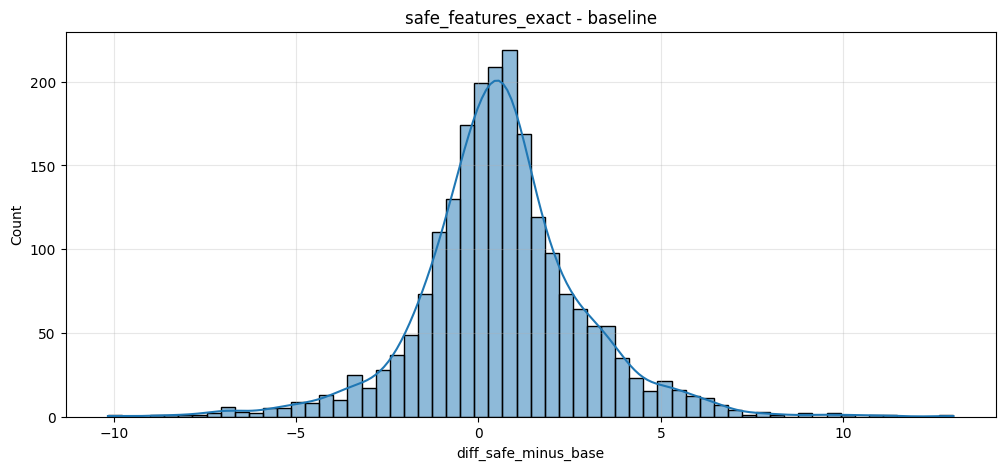

In [ ]:
print("=" * 90)
print("FINAL TRAINING EXACT")
print("=" * 90)


# Safe exact
safe_final_models = fit_ensemble(
    train_fe,
    safe_features,
    label="FINAL_SAFE_FEATURES_EXACT_747",
    fast_mode=False,
)

safe_valid_pred, _ = predict_ensemble(
    safe_final_models,
    valid_fe,
    safe_features,
)

submission_safe = valid_fe[["row_id"]].copy()
submission_safe["target"] = safe_valid_pred

submission_safe = (
    submission_safe
    .sort_values("row_id")[["target"]]
    .reset_index(drop=True)
)

submission_safe.to_csv(SAFE_SUBMISSION_PATH, index=False)

print("Saved safe exact:", SAFE_SUBMISSION_PATH)
display(submission_safe.head())
display(submission_safe.describe())

compare_final = pd.DataFrame({
    "baseline": submission_baseline["target"],
    "safe_features_exact": submission_safe["target"],
})

compare_final["diff_safe_minus_base"] = compare_final["safe_features_exact"] - compare_final["baseline"]

print("\nСравнение:")
display(compare_final.describe())

plt.figure(figsize=(12, 5))
sns.histplot(compare_final["diff_safe_minus_base"], bins=60, kde=True)
plt.title("safe_features_exact - baseline")
plt.grid(alpha=0.3)
plt.show()

## 9. Layout / Wake features по карте Азовской ВЭС


AZOV WIND FARM LAYOUT / WAKE FEATURES
Turbines file: data\azov_turbines_from_map.csv
Turbines shape: (26, 5)


,turbine_id,x_pixel,y_pixel,lat,lon
0,1,118.719900,35.835057,46.865061,38.691954
1,2,126.584630,81.057260,46.862580,38.692331
2,3,115.770625,137.093468,46.859477,38.691820
3,4,299.608711,34.851966,46.865387,38.700568
4,5,307.473442,80.074168,46.862890,38.700937



--- Геометрия ВЭС ---
Среднее ближайшее расстояние: 323.2 м
Медианное ближайшее расстояние: 328.7 м
Мин/макс ближайшее расстояние: 256.7 / 379.0 м
Главная ось, xy angle: 86.01°
Главная ось, compass: 3.99° / 183.99°
PCA explained variance: [0.86450917 0.13549083]


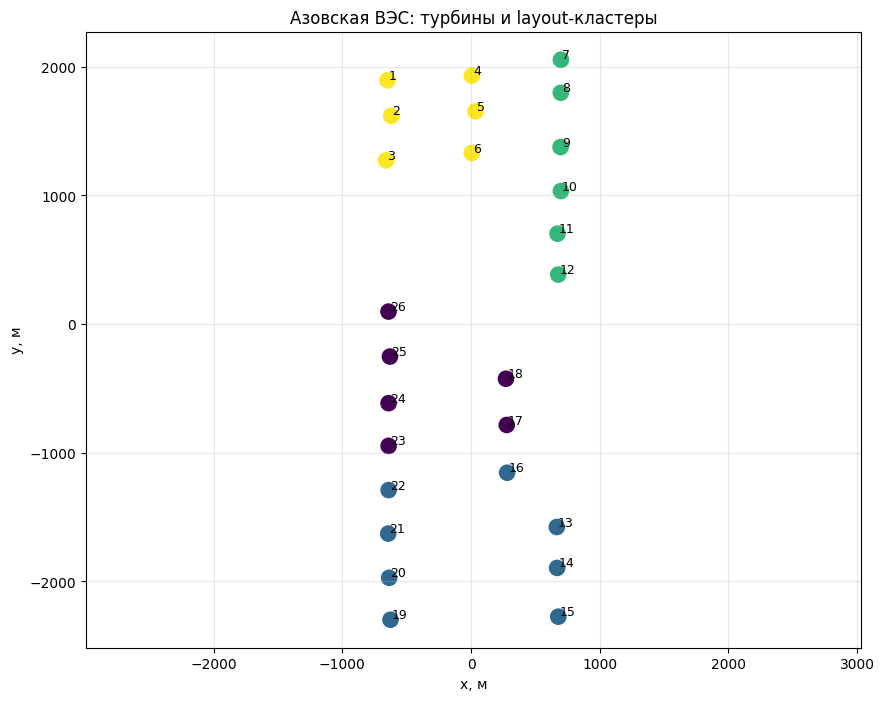

,turbine_id,x_pixel,y_pixel,lat,lon,x_m,y_m,layout_cluster
0,1,118.719900,35.835057,46.865061,38.691954,-649.321266,1892.677674,3
1,2,126.584630,81.057260,46.862580,38.692331,-620.655638,1616.522720,3
2,3,115.770625,137.093468,46.859477,38.691820,-659.590410,1271.133997,3
3,4,299.608711,34.851966,46.865387,38.700568,6.505910,1929.032677,3
4,5,307.473442,80.074168,46.862890,38.700937,34.547759,1651.046207,3
5,6,299.608711,132.178011,46.859989,38.700556,5.547335,1328.091420,3
6,7,490.328436,20.105595,46.866498,38.709655,698.339870,2052.687496,2
7,8,490.328436,61.395432,46.864192,38.709642,697.332144,1795.977916,2
8,9,490.328436,129.228737,46.860403,38.709620,695.676595,1374.240748,2
9,10,491.311527,184.281853,46.857330,38.709649,697.886047,1032.093193,2


,wind_from_deg,wake_pair_count,wake_risk_score,wake_risk_score_norm
0,0,69,24.313774,1.000000
1,5,72,23.039588,0.947594
2,10,64,20.820656,0.856332
3,15,58,18.155964,0.746736
4,20,51,15.686597,0.645173


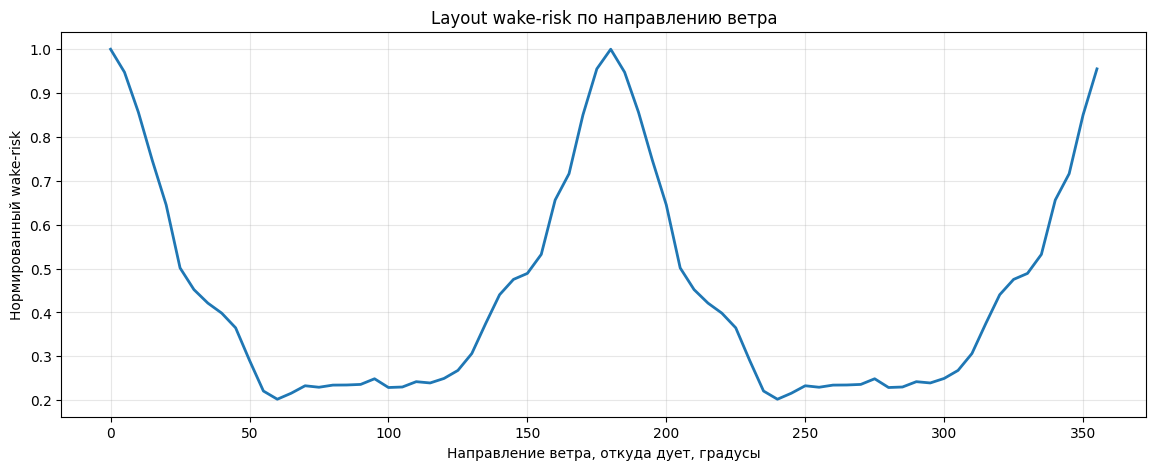

Saved wake table: outputs\pipeline_747\azov_wake_risk_by_direction_747.csv
Saved turbine layout: outputs\pipeline_747\azov_turbines_layout_clusters_747.csv

layout_cols: ['layout_wake_risk_120m', 'layout_wake_pair_count_120m', 'layout_axis_alignment', 'layout_axis_crosswind', 'layout_wake_x_wind120', 'layout_wake_x_wind120_cube']
safe_features: 147
features_layout: 153


In [10]:
# ============================================================
# LAYOUT / WAKE FEATURES ДЛЯ АЗОВСКОЙ ВЭС
# ============================================================

from pathlib import Path
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from scipy.spatial.distance import pdist, squareform

print("=" * 90)
print("AZOV WIND FARM LAYOUT / WAKE FEATURES")
print("=" * 90)

TURBINE_COORDS_PATH = Path("data/azov_turbines_from_map.csv")
LAYOUT_SUBMISSION_PATH = OUTPUT_DIR / "submission_safe_features_layout_wake_747.csv"
LAYOUT_REPORT_PATH = OUTPUT_DIR / "layout_wake_747_local_check.csv"

if not TURBINE_COORDS_PATH.exists():
    raise FileNotFoundError(
        f"Не найден файл {TURBINE_COORDS_PATH}. "
        "Положи azov_turbines_from_map.csv в папку data/"
    )

turbines = pd.read_csv(TURBINE_COORDS_PATH)

print("Turbines file:", TURBINE_COORDS_PATH)
print("Turbines shape:", turbines.shape)
display(turbines.head())

required_cols = {"lat", "lon"}
if not required_cols.issubset(turbines.columns):
    raise ValueError(f"В {TURBINE_COORDS_PATH} должны быть колонки lat и lon")

if "turbine_id" not in turbines.columns:
    turbines["turbine_id"] = np.arange(1, len(turbines) + 1)

if len(turbines) != 26:
    print(f"WARNING: ожидалось 26 турбин, а найдено {len(turbines)}")

# ------------------------------------------------------------
# 1. lat/lon -> локальные метры
# ------------------------------------------------------------

lat0 = turbines["lat"].mean()
lon0 = turbines["lon"].mean()

meters_per_deg_lat = 111_320
meters_per_deg_lon = 111_320 * np.cos(np.deg2rad(lat0))

turbines["x_m"] = (turbines["lon"] - lon0) * meters_per_deg_lon
turbines["y_m"] = (turbines["lat"] - lat0) * meters_per_deg_lat

XY = turbines[["x_m", "y_m"]].to_numpy()

# ------------------------------------------------------------
# 2. Расстояния, кластеры, главная ось
# ------------------------------------------------------------

D = squareform(pdist(XY))
D_for_nearest = D + np.eye(len(D)) * 10**9
nearest_dist = D_for_nearest.min(axis=1)

print("\n--- Геометрия ВЭС ---")
print(f"Среднее ближайшее расстояние: {nearest_dist.mean():.1f} м")
print(f"Медианное ближайшее расстояние: {np.median(nearest_dist):.1f} м")
print(f"Мин/макс ближайшее расстояние: {nearest_dist.min():.1f} / {nearest_dist.max():.1f} м")

N_LAYOUT_CLUSTERS = 4

kmeans_layout = KMeans(
    n_clusters=N_LAYOUT_CLUSTERS,
    random_state=RANDOM_STATE,
    n_init=30,
)

turbines["layout_cluster"] = kmeans_layout.fit_predict(XY)

pca_layout = PCA(n_components=2)
pca_layout.fit(XY)

main_axis = pca_layout.components_[0]

# x=east, y=north
axis_angle_xy_deg = (np.rad2deg(np.arctan2(main_axis[1], main_axis[0])) + 360) % 360

# compass: 0=N, 90=E
farm_axis_compass_deg = (90 - axis_angle_xy_deg) % 360

print(f"Главная ось, xy angle: {axis_angle_xy_deg:.2f}°")
print(f"Главная ось, compass: {farm_axis_compass_deg:.2f}° / {(farm_axis_compass_deg + 180) % 360:.2f}°")
print("PCA explained variance:", pca_layout.explained_variance_ratio_)

plt.figure(figsize=(10, 8))
plt.scatter(
    turbines["x_m"],
    turbines["y_m"],
    c=turbines["layout_cluster"],
    s=120,
)

for _, r in turbines.iterrows():
    plt.text(
        r["x_m"] + 10,
        r["y_m"] + 10,
        str(int(r["turbine_id"])),
        fontsize=9,
    )

plt.axis("equal")
plt.grid(alpha=0.3)
plt.title("Азовская ВЭС: турбины и layout-кластеры")
plt.xlabel("x, м")
plt.ylabel("y, м")
plt.show()

display(turbines)

# ------------------------------------------------------------
# 3. Wake-risk table по направлению ветра
# ------------------------------------------------------------

def compute_wake_risk_for_direction(
    XY,
    wind_from_deg,
    lateral_threshold_m=260,
    max_downwind_m=2500,
    decay_downwind_m=800,
):
    """
    wind_from_deg — направление, ОТКУДА дует ветер:
    0 = с севера, 90 = с востока.
    Поток идёт КУДА: wind_from_deg + 180.
    """
    flow_to_deg = (wind_from_deg + 180) % 360
    theta = np.deg2rad(flow_to_deg)

    # x=east, y=north
    flow_vec = np.array([np.sin(theta), np.cos(theta)])
    side_vec = np.array([np.cos(theta), -np.sin(theta)])

    pair_count = 0
    weighted_risk = 0.0

    n = len(XY)

    for i in range(n):
        for j in range(n):
            if i == j:
                continue

            delta = XY[j] - XY[i]

            downwind = np.dot(delta, flow_vec)
            lateral = abs(np.dot(delta, side_vec))

            if (
                downwind > 0
                and downwind <= max_downwind_m
                and lateral <= lateral_threshold_m
            ):
                pair_count += 1
                weighted_risk += (
                    np.exp(-downwind / decay_downwind_m)
                    * np.exp(-((lateral / lateral_threshold_m) ** 2))
                )

    return pair_count, weighted_risk


directions = np.arange(0, 360, 5)

wake_rows = []

for d in directions:
    pair_count, risk_score = compute_wake_risk_for_direction(
        XY,
        wind_from_deg=d,
        lateral_threshold_m=260,
        max_downwind_m=2500,
        decay_downwind_m=800,
    )

    wake_rows.append({
        "wind_from_deg": d,
        "wake_pair_count": pair_count,
        "wake_risk_score": risk_score,
    })

wake_table = pd.DataFrame(wake_rows)

if wake_table["wake_risk_score"].max() > 0:
    wake_table["wake_risk_score_norm"] = (
        wake_table["wake_risk_score"] / wake_table["wake_risk_score"].max()
    )
else:
    wake_table["wake_risk_score_norm"] = 0.0

display(wake_table.head())

plt.figure(figsize=(14, 5))
plt.plot(
    wake_table["wind_from_deg"],
    wake_table["wake_risk_score_norm"],
    linewidth=2,
)
plt.title("Layout wake-risk по направлению ветра")
plt.xlabel("Направление ветра, откуда дует, градусы")
plt.ylabel("Нормированный wake-risk")
plt.grid(alpha=0.3)
plt.show()

wake_table.to_csv(OUTPUT_DIR / "azov_wake_risk_by_direction_747.csv", index=False)
turbines.to_csv(OUTPUT_DIR / "azov_turbines_layout_clusters_747.csv", index=False)

print("Saved wake table:", OUTPUT_DIR / "azov_wake_risk_by_direction_747.csv")
print("Saved turbine layout:", OUTPUT_DIR / "azov_turbines_layout_clusters_747.csv")

# ------------------------------------------------------------
# 4. Добавление layout-фичей в train_fe / valid_fe
# ------------------------------------------------------------

def circular_diff_deg(a, b):
    return ((a - b + 180) % 360) - 180


def add_layout_wake_features(frame, direction_col="wind_direction_120m"):
    out = frame.copy()

    added_cols = []

    if direction_col not in out.columns:
        print(f"Нет {direction_col}, layout wake features не добавлены.")
        return out, added_cols

    # В baseline направление масштабировалось *1000
    wind_from_deg = (out[direction_col] * 1000) % 360

    # lookup к ближайшим 5 градусам
    rounded_deg = (np.round(wind_from_deg / 5) * 5) % 360

    risk_map = dict(
        zip(
            wake_table["wind_from_deg"],
            wake_table["wake_risk_score_norm"],
        )
    )

    pair_map = dict(
        zip(
            wake_table["wind_from_deg"],
            wake_table["wake_pair_count"],
        )
    )

    out["layout_wake_risk_120m"] = rounded_deg.map(risk_map)
    out["layout_wake_pair_count_120m"] = rounded_deg.map(pair_map)

    out["layout_wake_risk_120m"] = (
        out["layout_wake_risk_120m"]
        .fillna(wake_table["wake_risk_score_norm"].median())
    )

    out["layout_wake_pair_count_120m"] = (
        out["layout_wake_pair_count_120m"]
        .fillna(wake_table["wake_pair_count"].median())
    )

    added_cols += [
        "layout_wake_risk_120m",
        "layout_wake_pair_count_120m",
    ]

    # Alignment с главной осью ВЭС.
    # cos(2*angle) делает ось симметричной: 0° и 180° одинаковые.
    diff_axis = circular_diff_deg(wind_from_deg, farm_axis_compass_deg)

    out["layout_axis_alignment"] = np.cos(2 * np.deg2rad(diff_axis))
    out["layout_axis_crosswind"] = np.sin(2 * np.deg2rad(diff_axis))

    added_cols += [
        "layout_axis_alignment",
        "layout_axis_crosswind",
    ]

    if "wind_speed_120m" in out.columns:
        out["layout_wake_x_wind120"] = (
            out["layout_wake_risk_120m"] * out["wind_speed_120m"]
        )

        out["layout_wake_x_wind120_cube"] = (
            out["layout_wake_risk_120m"] * (out["wind_speed_120m"] ** 3)
        )

        added_cols += [
            "layout_wake_x_wind120",
            "layout_wake_x_wind120_cube",
        ]

    return out, added_cols


train_fe_layout, layout_cols = add_layout_wake_features(
    train_fe,
    direction_col="wind_direction_120m",
)

valid_fe_layout, _ = add_layout_wake_features(
    valid_fe,
    direction_col="wind_direction_120m",
)

layout_cols = [
    c for c in layout_cols
    if c in train_fe_layout.columns and c in valid_fe_layout.columns
]

features_layout = list(dict.fromkeys([
    c for c in safe_features + layout_cols
    if c in train_fe_layout.columns and c in valid_fe_layout.columns
]))

print("\nlayout_cols:", layout_cols)
print("safe_features:", len(safe_features))
print("features_layout:", len(features_layout))

## 10. Локальная проверка и финальный submission layout/wake


LOCAL CHECK: SAFE vs SAFE + LAYOUT WAKE

Обучение ансамбля: local_safe_features
n_features: 147

Обучение ансамбля: local_safe_plus_layout_wake
n_features: 153


,experiment,n_features,mae,delta_vs_safe
0,safe_features,147,7.741612,0.000000
1,safe_plus_layout_wake,153,7.744389,0.002777


Saved layout report: outputs\pipeline_747\layout_wake_747_local_check.csv
FINAL TRAINING: SAFE + LAYOUT WAKE

Обучение ансамбля: FINAL_SAFE_PLUS_LAYOUT_WAKE
n_features: 153
Saved layout submission: outputs\pipeline_747\submission_safe_features_layout_wake_747.csv
(2126, 1)


,target
0,5.568937
1,15.215657
2,16.449536
3,16.533825
4,13.453576


,target
count,2126.000000
mean,39.744757
std,25.622476
min,0.000000
25%,14.446095
50%,40.720471
75%,64.823151
max,79.273885


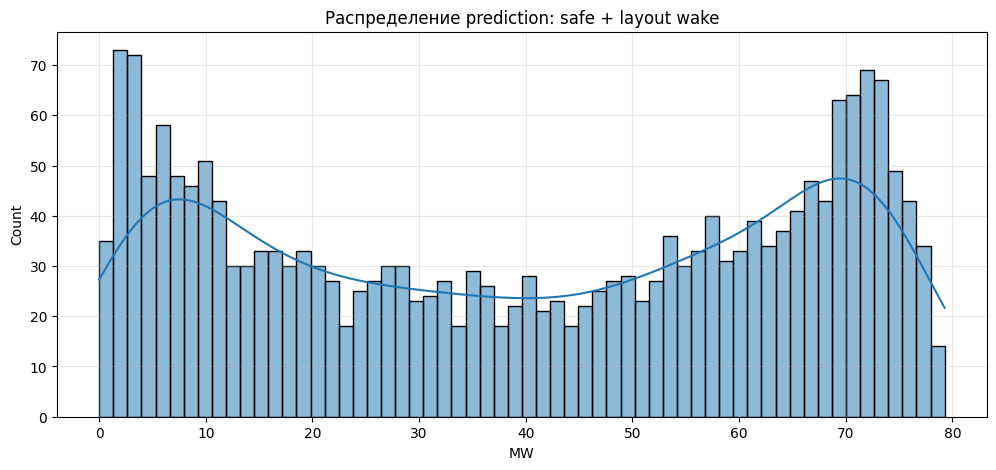

In [11]:
# ============================================================
# LOCAL CHECK + FINAL SUBMISSION: safe_features + layout wake
# ============================================================

print("=" * 90)
print("LOCAL CHECK: SAFE vs SAFE + LAYOUT WAKE")
print("=" * 90)

FAST_LOCAL_CHECK = True

split_idx = int(len(train_fe) * 0.8)

train_part_safe = train_fe.iloc[:split_idx].copy().reset_index(drop=True)
eval_part_safe = train_fe.iloc[split_idx:].copy().reset_index(drop=True)

train_part_layout = train_fe_layout.iloc[:split_idx].copy().reset_index(drop=True)
eval_part_layout = train_fe_layout.iloc[split_idx:].copy().reset_index(drop=True)

y_eval_true = eval_part_safe["target"].clip(0, INSTALLED_CAPACITY_MW).to_numpy()

layout_results = []

safe_local_models = fit_ensemble(
    train_part_safe,
    safe_features,
    label="local_safe_features",
    fast_mode=FAST_LOCAL_CHECK,
)

safe_eval_pred, _ = predict_ensemble(
    safe_local_models,
    eval_part_safe,
    safe_features,
)

safe_mae = mean_absolute_error(y_eval_true, safe_eval_pred)

layout_results.append({
    "experiment": "safe_features",
    "n_features": len(safe_features),
    "mae": safe_mae,
})

layout_local_models = fit_ensemble(
    train_part_layout,
    features_layout,
    label="local_safe_plus_layout_wake",
    fast_mode=FAST_LOCAL_CHECK,
)

layout_eval_pred, _ = predict_ensemble(
    layout_local_models,
    eval_part_layout,
    features_layout,
)

layout_mae = mean_absolute_error(y_eval_true, layout_eval_pred)

layout_results.append({
    "experiment": "safe_plus_layout_wake",
    "n_features": len(features_layout),
    "mae": layout_mae,
})

layout_results_df = pd.DataFrame(layout_results)
layout_results_df["delta_vs_safe"] = layout_results_df["mae"] - safe_mae
layout_results_df = layout_results_df.sort_values("mae").reset_index(drop=True)

display(layout_results_df)

layout_results_df.to_csv(LAYOUT_REPORT_PATH, index=False)

print("Saved layout report:", LAYOUT_REPORT_PATH)

# ------------------------------------------------------------
# Финальное обучение layout-кандидата
# ------------------------------------------------------------

print("=" * 90)
print("FINAL TRAINING: SAFE + LAYOUT WAKE")
print("=" * 90)

layout_final_models = fit_ensemble(
    train_fe_layout,
    features_layout,
    label="FINAL_SAFE_PLUS_LAYOUT_WAKE",
    fast_mode=False,
)

layout_valid_pred, _ = predict_ensemble(
    layout_final_models,
    valid_fe_layout,
    features_layout,
)

submission_layout = valid_fe_layout[["row_id"]].copy()
submission_layout["target"] = layout_valid_pred

submission_layout = (
    submission_layout
    .sort_values("row_id")[["target"]]
    .reset_index(drop=True)
)

submission_layout.to_csv(LAYOUT_SUBMISSION_PATH, index=False)

print("Saved layout submission:", LAYOUT_SUBMISSION_PATH)
print(submission_layout.shape)

display(submission_layout.head())
display(submission_layout.describe())

plt.figure(figsize=(12, 5))
sns.histplot(submission_layout["target"], bins=60, kde=True)
plt.title("Распределение prediction: safe + layout wake")
plt.xlabel("MW")
plt.grid(alpha=0.3)
plt.show()

## 9. Итог

In [12]:
print("=" * 90)
print("FILES")
print("=" * 90)

print("Safe exact, стабильный файл:")
print(SAFE_SUBMISSION_PATH)
print("exists:", SAFE_SUBMISSION_PATH.exists())

print("\nLayout/wake candidate:")
try:
    print(LAYOUT_SUBMISSION_PATH)
    print("exists:", LAYOUT_SUBMISSION_PATH.exists())
except NameError:
    print("Layout/wake блок ещё не запускался.")

print("\nLayout report:")
try:
    print(LAYOUT_REPORT_PATH)
    print("exists:", LAYOUT_REPORT_PATH.exists())
except NameError:
    print("Layout/wake блок ещё не запускался.")

print("\nДля метрики основной файл:")
print(SAFE_SUBMISSION_PATH)

print("\nДля необычного подхода / жюри:")
try:
    print(LAYOUT_SUBMISSION_PATH)
except NameError:
    pass

FILES
Safe exact, стабильный файл:
outputs\pipeline_747\submission_safe_features_exact_747.csv
exists: True

Layout/wake candidate:
outputs\pipeline_747\submission_safe_features_layout_wake_747.csv
exists: True

Layout report:
outputs\pipeline_747\layout_wake_747_local_check.csv
exists: True

Для метрики основной файл:
outputs\pipeline_747\submission_safe_features_exact_747.csv

Для необычного подхода / жюри:
outputs\pipeline_747\submission_safe_features_layout_wake_747.csv
